# MPS optimization JW $Z_4^{TF}$ system

Created: 21-08-2026

Objectives:
* Use methods from [previous notebook](random_fdlu_noising_mps_optimization_sweep.ipynb), sweep results to save. Take a fermion decorated domain wall state and JW transform, analyse that system instead. One can show the resulting state is stabilized by terms of the form $ZZZ$ centered on even (pre-JW fermion sites) and $XXX$ centered on odd (pre-JW spin sites). The resulting ground state looks like $$\ket\psi = \sum_{b_i} \ldots \ket{\ldots, b_i, b_i + b_{i+1}, b_{i+1},\ldots}$$

# Imports

In [1]:
import numpy as np

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from operator import mul

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from scipy.stats import ortho_group

In [8]:
from collections import Counter

In [9]:
import pandas as pd

In [10]:
from time import time

In [11]:
from humanize import naturalsize

# Definitions
## Construct cluster state

In [12]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [13]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [14]:
np_CZ = np.diag([1,1,1,-1])

In [15]:
np_CZ = np_CZ.reshape((2,)*4)

In [16]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [17]:
np_hadamard = np.pow(2, -1/2)*np.array([
    [1,1],
    [1,-1]
])

In [18]:
qu_hadamard = qtn.Tensor(data=np_hadamard, inds=('k', 'b'), tags='Had')

In [19]:
def get_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'kh_{i}',
            'k2': f'k{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    hadamard_layer = [
        qu_hadamard.reindex({
            'b': f'kh_{i}',
            'k': f'k{i}'
        })
        for i in range(1, num_sites, 2)
    ]
    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
        + hadamard_layer
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

## Construct product state

In [20]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [21]:
np_up_Z_state = np.array([1,0])

In [22]:
qu_up_Z_state = qtn.Tensor(
    data=np_up_Z_state,
    inds=('k',),
    tags='prod'
)

In [23]:
alternating_states = [
    qu_up_X_state,
    qu_up_Z_state
]

def get_product_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        alternating_states[i%2].reindex({'k': f'k{i}'})
        for i in range(num_sites)
    ]

    out = qtn.TensorNetwork(
        product_state_tensors,
        virtual=True
    )
    out.mangle_inner_()

    return out

## Symmetries

In [24]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [25]:
np_I = np.array([
    [1,0],
    [0,1]
])

np_X = np.array([
    [0,1],
    [1,0]
])

np_Y = np.array([
    [0,-1j],
    [1j,0]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [26]:
qu_I = qtn.Tensor(
    np_I,
    inds=['k', 'b'],
    tags='X'
)

qu_X = qtn.Tensor(
    np_X,
    inds=['k', 'b'],
    tags='X'
)

qu_Y = qtn.Tensor(
    np_Y,
    inds=['k', 'b'],
    tags='Y'
)

qu_Z = qtn.Tensor(
    np_Z,
    inds=['k', 'b'],
    tags='Z'
)

In [27]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [28]:
def get_multisite_qu_I(num_sites):
    np_many_I = multikron([np_I]*num_sites)

    out = qtn.Tensor(
        np_many_I,
        inds=['k', 'b'],
        tags='mulit_site_I',
    )

    return out

In [29]:
qu_unit_cell_fp = (
    qu_I.reindex({'k': 'ks', 'b': 'bs'})
    & qu_Z.reindex({'k': 'kf', 'b': 'bf'})
).contract()

qu_unit_cell_fp = qu_unit_cell_fp.fuse({
    'k': ['ks', 'kf'],
    'b': ['bs', 'bf']
})

In [30]:
"""
def get_multisite_qu_fp(num_sites):
    assert (num_sites%2)==0

    num_unit_cells = (num_sites//2)

    np
"""

'\ndef get_multisite_qu_fp(num_sites):\n    assert (num_sites%2)==0\n\n    num_unit_cells = (num_sites//2)\n\n    np\n'

Decompose T symmetry as $MK$:

In [31]:
np_00 = np.array([[1,0], [0,0]])
np_11 = np.array([[0,0], [0,1]])

In [32]:
def tensor_product_operators(op_1, op_2):
    out = (
        op_1[..., np.newaxis, np.newaxis]
        *op_2[np.newaxis, np.newaxis, ...]
    )

    return out

In [33]:
np_M = (
    tensor_product_operators(np_X, np_00)
    + tensor_product_operators(np_Y, np_11)
)

In [34]:
qu_M = qtn.Tensor(
    np_M,
    inds=['ks', 'bs', 'kf', 'bf']
)

## Defect operators

In [35]:
# I don't think we're using this anymore
def get_rho_A_purity(A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A
    t2 = A.conj().reindex(transpose_dict)
    t3 = A.reindex(transpose_dict | alternative_vertical_index_dict)
    t4 = A.conj().reindex(alternative_vertical_index_dict)

    t = (t1 & t2 & t3 & t4)

    return jnp.real(t.contract())

In [36]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [37]:
def normalize_A(A):
    # Ensure trace = 1
    trace = jnp.real((A & A.conj()).contract())
    A = A.multiply(trace**(-0.5), spread_over=A.num_tensors)

    # Equalize norms
    norms = [
        jnp.sqrt(jnp.real((a & a.conj()).contract()))
        for a in A.tensors
    ]
    geometric_mean_norms = jnp.pow(reduce(mul, norms), 1/(A.num_tensors))

    for a, norm in zip(A.tensors, norms):
        a.modify(data=a.data*geometric_mean_norms/norm)

    return A

In [38]:
alternative_vertical_index_dict = {
    'vLV': 'vLV_alt',
    'vRV': 'vRV_alt'
}

In [39]:
def get_rho_A_purity(A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A
    t2 = A.conj().reindex(transpose_dict)
    t3 = A.reindex(transpose_dict | alternative_vertical_index_dict)
    t4 = A.conj().reindex(alternative_vertical_index_dict)

    t = (t1 & t2 & t3 & t4)

    return jnp.real(t.contract())

In [40]:
def get_rho_A_rho_overlap(rho, A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A.reindex(transpose_dict)
    t2 = A.conj()

    t = (rho & t1 & t2)

    return jnp.real(t.contract())

In [41]:
def loss_func(A, rho, rho_purity):

    out = jnp.real(
        rho_purity
        + get_rho_A_purity(A)
        -2*get_rho_A_rho_overlap(rho, A)
    )

    return out

In [42]:
def get_initial_rho_mps_representation(domains_dict):
    symmetry_sites = domains_dict['symmetry_sites']
    horizontal_bond_dimension = domains_dict['mps_horizontal_bond_dimension']
    vertical_bond_dimension = domains_dict['mps_vertical_bond_dimension']

    i = symmetry_sites[0]
    leftmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            vertical_bond_dimension,
            2,
            horizontal_bond_dimension
        )),
        inds=('vLV', f'k{i}', f'vH{i}')
    )

    interior_mps_tensors = [
        qtn.Tensor(
            data=random_uniform_complex((
                horizontal_bond_dimension,
                2,
                horizontal_bond_dimension
            )),
            inds=(f'vH{i-1}', f'k{i}', f'vH{i}')
        )
        for i in symmetry_sites[1:-1]
    ]

    i = symmetry_sites[-1]
    rightmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            horizontal_bond_dimension,
            2,
            vertical_bond_dimension
        )),
        inds=(f'vH{i-1}', f'k{i}', 'vRV')
    )

    mps_tensors = [
        leftmost_mps_tensor,
        *interior_mps_tensors,
        rightmost_mps_tensor
    ]
    
    A = qtn.TensorNetwork(mps_tensors)

    return A

In [43]:
def get_rho_mps_representation(qt_rho, rho_purity, domains_dict):
    A = get_initial_rho_mps_representation(domains_dict)

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=500)

    tnopt = qtn.TNOptimizer(
        A_opt,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="adam",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=2000)

    return A_opt, tnopt.losses, tnopt.loss_best

In [44]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl, kr, bl, br]
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl'), edm.ind_size('kl')),
        inds=['kl', 'bl'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br'), edm.ind_size('kr')),
        inds=['kr', 'br'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl': 'bl', 'bl':'kl'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr', 'br'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr': 'br', 'br':'kr'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl', 'bl'])

    return (left_defect_op, right_defect_op), scores

In [45]:
def get_rho_tilde(mps_decomp, domains_dict):
    # rho_tilde is a reduced density matrix with the bra part complex conjugated
    A = mps_decomp

    # Left side
    A_l = A.tensors[next(iter(A.ind_map['vLV']))]
    k_left_ind = min(domains_dict['symmetry_sites'])
    dummy_left_index = f'vH{k_left_ind}'
    
    tn_l = (
        A_l
        &
        A_l.conj().reindex({
            f'k{k_left_ind}': f'b{k_left_ind}',
            dummy_left_index: 'dl',
        })
    )
    tn_l = tn_l.contract()

    left_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=[f'k{k_left_ind}', dummy_left_index],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    # Right side
    A_r = A.tensors[next(iter(A.ind_map['vRV']))]
    k_right_ind = max(domains_dict['symmetry_sites'])
    dummy_right_index = f'vH{k_right_ind-1}'

    tn_r = (
        A_r
        &
        A_r.conj().reindex({
            f'k{k_right_ind}': f'b{k_right_ind}',
            dummy_right_index: 'dr',
        })
    )
    tn_r = tn_r.contract()

    right_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=[f'k{k_right_ind}', dummy_right_index],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    ket_tensors = [
        *left_decomp.tensors[:-1],
        *[t for t in mps_decomp.tensors[1:-1]],
        *right_decomp.tensors[:-1]
    ]

    bra_tensors = [
        left_decomp.tensors[-1].conj().reindex({'dl': dummy_left_index}),
        *[
            t.reindex({f'k{i}': f'b{i}'})
            for t, i in zip(mps_decomp.tensors[1:-1], domains_dict['symmetry_sites'][1:-1])
        ],
        right_decomp.tensors[-1].conj().reindex({'dr': dummy_right_index})
    ]

    ket_tn = qtn.TensorNetwork(ket_tensors)
    bra_tn = qtn.TensorNetwork(bra_tensors).mangle_inner_()

    rho_tilde = ket_tn & bra_tn

    return rho_tilde

In [46]:
def get_edm_from_rho(rho, domains_dict):
    consistency_cond = (
        len(domains_dict['symmetry_sites'])%2 == 0
        and domains_dict['symmetry_sites'][0]%2 == 0
        and len(domains_dict['left_defect_sites'])%2 == 0
        and len(domains_dict['right_defect_sites'])%2 == 0
    )
    assert consistency_cond, "Sites not blocks of unit cells"
    # Also works for rho_tilde (rho after partial conjugation)

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_gates = [
        qu_M.conj().reindex({
            'ks': f'b{i}', 'bs':f'i{i}',
            'kf': f'b{i+1}', 'bf':f'i{i+1}',
        })
        for i in domains_dict['left_defect_sites'][::2]
    ]

    central_gates = [
        qu_M.conj().reindex({
            'ks': f'k{i}', 'bs':f'b{i}',
            'kf': f'k{i+1}', 'bf':f'b{i+1}',
        })
        for i in central_sites[::2]
    ]

    right_gates = [
        qu_M.conj().reindex({
            'ks': f'b{i}', 'bs':f'i{i}',
            'kf': f'b{i+1}', 'bf':f'i{i+1}',
        })
        for i in domains_dict['right_defect_sites'][::2]
    ]

    all_tensors = [
        rho.reindex(
            {f'b{i}': f'i{i}' for i in domains_dict['left_defect_sites']}
            | {f'b{i}': f'i{i}' for i in domains_dict['right_defect_sites']}
        ),
        *left_gates,
        *central_gates,
        *right_gates
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = (
        qtn.TensorNetwork(all_tensors)
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [47]:
def get_defect_ops_and_indices_from_mps_decomposition(
    qt_rho, mps_decomp, domains_dict, partial_conjugation=False):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    if partial_conjugation:
        rho_tilde = get_rho_tilde(mps_decomp, domains_dict)
        edm = get_edm_from_rho(rho_tilde, domains_dict)
    else:
        edm = get_edm_from_rho(rho, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    """
    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )
    """

    np_left_rdm = (
        rho_defect_l
        .transpose('kl', 'bl')
        .data
    )
    
    np_left_defect_op = (
        left_defect_operator
        .transpose('kl', 'bl')
        .data
    )

    np_unit_cell_fp = (
        qu_unit_cell_fp
        .transpose('k', 'b')
        .data
    )

    """
    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & qu_unit_cell_fp.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'kl': 'ki2', 'bl': 'ki3'})
        & qu_unit_cell_fp.reindex({'b': 'ki3', 'k': 'bl'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()
    """

    left_defect_op_invariant = np.trace(
        np_unit_cell_fp
        @ np_left_defect_op.conj().T
        @ np_unit_cell_fp
        @ np_left_defect_op
        @ np_left_rdm
    )

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    np_right_rdm = (
        rho_defect_r
        .transpose('kr', 'br')
        .data
    )

    np_right_defect_op = (
        right_defect_operator
        .transpose('kr', 'br')
        .data
        .T
    )

    """
    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )
    """

    """
    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & qu_unit_cell_fp.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'kr': 'ki2', 'br': 'ki3'})
        & qu_unit_cell_fp.reindex({'b': 'ki3', 'k': 'br'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()
    """

    right_defect_op_invariant = np.trace(
        np_unit_cell_fp
        @ np_right_defect_op.conj().T
        @ np_unit_cell_fp
        @ np_right_defect_op
        @ np_right_rdm
    )

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        overlap
    )

    return out

In [48]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [49]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [50]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

## Apply random unitary to groundstate

In [51]:
# Hard code warning
def generate_random_symmetry_respecting_unitary():
    o = ortho_group.rvs(4)

    np_H = np.pow(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

    u = np_W @ o @ (np_W.conj().T)

    return u

In [52]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi, domains_dict):
    num_sites = domains_dict['num_system_sites']

    depth = domains_dict['fdlu_depth']
    offset = domains_dict['fdlu_offset']

    all_circuit_lists = [
        list() for _ in range(depth)
    ]

    for layer, circuit_list in enumerate(all_circuit_lists):
        delta = layer
    
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta+offset)%num_sites
            site_2 = ((2*i)+1+delta+offset)%num_sites

            u = generate_random_symmetry_respecting_unitary()

            inds=[
                f'k_{layer+1}_{site_1}',
                f'k_{layer+1}_{site_2}',
                f'k_{layer}_{site_1}',
                f'k_{layer}_{site_2}'
            ]
            
            qu_u = qtn.Tensor(
                u.reshape((2,)*4),
                inds=inds,
                tags=f'Layer_{layer}'
            )

            circuit_list.append(qu_u)

    all_tensors = (
        [psi.reindex({f'k{i}': f'k_0_{i}' for i in range(num_sites)})]
        + sum(all_circuit_lists, start=[])
    )

    out = (
        qtn
        .TensorNetwork(all_tensors, virtual=False)
        .mangle_inner_()
        .reindex({f'k_{depth}_{i}': f'k{i}' for i in range(num_sites)}) 
    )

    return out

# Test - Cluster state

In [53]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10, 11],
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [54]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [55]:
(cluster_psi & cluster_psi.conj()).contract()

np.float64(0.9999999999999982)

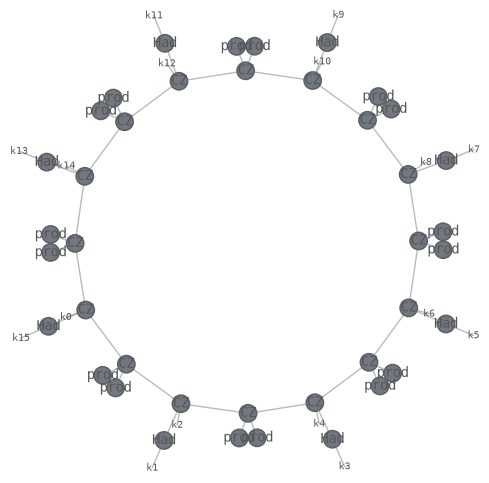

In [56]:
cluster_psi.draw()

In [57]:
rho = get_rdm_from_quimb_psi(cluster_psi, domains_dict['symmetry_sites'])

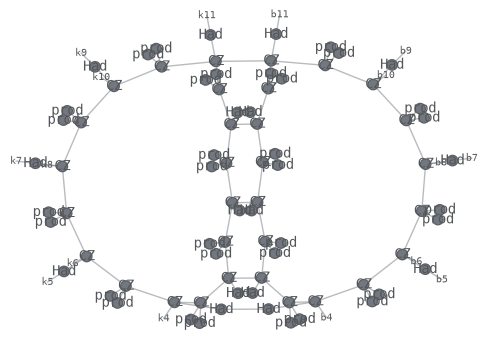

In [58]:
rho.draw()

In [59]:
rho.outer_inds()

('k4',
 'k6',
 'k8',
 'k10',
 'k5',
 'k7',
 'k9',
 'k11',
 'b4',
 'b6',
 'b8',
 'b10',
 'b5',
 'b7',
 'b9',
 'b11')

In [60]:
rho_purity = get_purity_from_quimb_rdm(rho)
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)

/Users/kierancooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(


In [61]:
rho_purity

0.24999999999999922

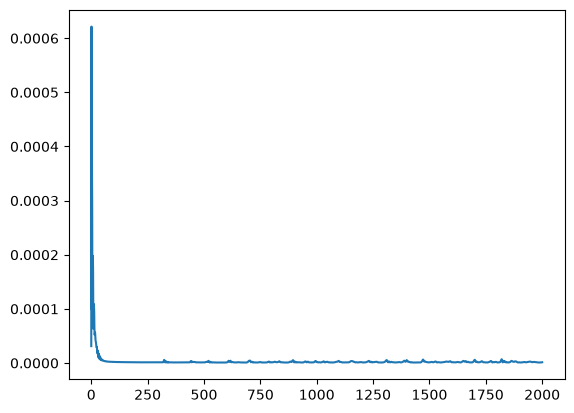

In [62]:
plt.plot(opt_out[1])

In [63]:
opt_out[1][-10:]

[9.834766387939453e-07,
 9.5367431640625e-07,
 1.0132789611816406e-06,
 1.043081283569336e-06,
 1.0728836059570312e-06,
 1.043081283569336e-06,
 1.1324882507324219e-06,
 1.2218952178955078e-06,
 1.2516975402832031e-06,
 1.4007091522216797e-06]

## Partial conjugation defect operators

In [64]:
defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(
    rho,
    opt_out[0],
    domains_dict,
    partial_conjugation=True
)

In [65]:
np.round(defect_opt_out[0], 3)

array([0.25, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  ])

In [66]:
defect_opt_out[3]

np.complex128(-0.9621879640917472+0j)

In [67]:
defect_opt_out[4]

np.complex128(-0.9483328989043003+0j)

In [68]:
defect_opt_out[-2]

[np.float64(0.7190503371982734),
 np.float64(0.9989028352828867),
 np.float64(0.9989028355059395),
 np.float64(0.99890283550594),
 np.float64(0.9989028355059397),
 np.float64(0.99890283550594),
 np.float64(0.9989028355059396),
 np.float64(0.9989028355059395),
 np.float64(0.9989028355059395),
 np.float64(0.9989028355059397),
 np.float64(0.9989028355059398),
 np.float64(0.9989028355059393),
 np.float64(0.9989028355059398),
 np.float64(0.9989028355059395),
 np.float64(0.9989028355059398),
 np.float64(0.9989028355059394),
 np.float64(0.9989028355059397),
 np.float64(0.9989028355059396),
 np.float64(0.9989028355059395),
 np.float64(0.99890283550594),
 np.float64(0.9989028355059404),
 np.float64(0.9989028355059397),
 np.float64(0.9989028355059393),
 np.float64(0.99890283550594),
 np.float64(0.99890283550594),
 np.float64(0.99890283550594),
 np.float64(0.9989028355059398),
 np.float64(0.99890283550594),
 np.float64(0.9989028355059397),
 np.float64(0.9989028355059395),
 np.float64(0.9989028355

In [69]:
defect_opt_out[1]

Tensor(shape=(4, 4), inds=('kl', 'bl'), tags=oset([]))

In [70]:
np.round(defect_opt_out[1].data, 3)

array([[-0.009+0.137j, -0.   -0.j   , -0.   +0.j   ,  0.955+0.263j],
       [ 0.   -0.j   , -0.009+0.137j,  0.955+0.262j,  0.   +0.j   ],
       [-0.   +0.j   ,  0.139+0.981j, -0.137-0.009j,  0.   +0.j   ],
       [ 0.139+0.981j, -0.   -0.j   ,  0.   -0.j   , -0.137-0.009j]])

In [71]:
left_fuse_map = {
    'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
    'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
}
right_fuse_map = {
    'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
    'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
}

In [72]:
left_fuse_map

{'kl': ['k4', 'k5'], 'bl': ['b4', 'b5']}

In [73]:
left_defect_op = defect_opt_out[1].unfuse(
    left_fuse_map,
    shape_map={'kl': [2,2], 'bl': [2,2]}
)

In [74]:
left_decomp = qtn.tensor_core.tensor_split(
    left_defect_op,
    left_inds=['k4', 'b4'],
    method='svd',
    #cutoff=1e-3,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vRV'
)

In [75]:
left_decomp.tensors[1].data

array([1.98100379e+00, 2.74997263e-01, 6.44299218e-04, 2.68193212e-04])

Well approximated as not entangled.

In [76]:
np.round(defect_opt_out[2].data, 3)

array([[-0.079+0.14j ,  0.872+0.462j, -0.   +0.j   , -0.   -0.j   ],
       [ 0.512-0.844j,  0.14 +0.079j, -0.   +0.j   ,  0.   +0.j   ],
       [ 0.   +0.j   ,  0.   -0.j   ,  0.14 +0.079j,  0.512-0.844j],
       [ 0.   +0.j   ,  0.   +0.j   ,  0.872+0.462j, -0.079+0.14j ]])

In [77]:
right_defect_op = defect_opt_out[2].unfuse(
    right_fuse_map,
    shape_map={'kr': [2,2], 'br': [2,2]}
)

In [78]:
np.round(right_defect_op.data, 3)

array([[[[-0.079+0.14j ,  0.872+0.462j],
         [-0.   +0.j   , -0.   -0.j   ]],

        [[ 0.512-0.844j,  0.14 +0.079j],
         [-0.   +0.j   ,  0.   +0.j   ]]],


       [[[ 0.   +0.j   ,  0.   -0.j   ],
         [ 0.14 +0.079j,  0.512-0.844j]],

        [[ 0.   +0.j   ,  0.   +0.j   ],
         [ 0.872+0.462j, -0.079+0.14j ]]]])

In [79]:
right_fuse_map

{'kr': ['k10', 'k11'], 'br': ['b10', 'b11']}

In [80]:
right_decomp = qtn.tensor_core.tensor_split(
    right_defect_op,
    left_inds=['k10', 'b10'],
    method='svd',
    #cutoff=1e-3,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vRV'
)

In [81]:
right_decomp.tensors[1].data

array([1.45335939e+00, 1.37395286e+00, 1.26335145e-04, 1.19436607e-04])

## No partial conjugation defect operators

In [82]:
defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(
    rho,
    opt_out[0],
    domains_dict,
    partial_conjugation=False
)

In [83]:
np.round(defect_opt_out[0], 3)

array([0.25])

In [84]:
defect_opt_out[3]

np.complex128(-0.9999999999999984+0j)

In [85]:
defect_opt_out[4]

np.complex128(-0.9999999999999986+0j)

Good overlaps. How to compute the invariant?

In [86]:
defect_opt_out[1]

Tensor(shape=(4, 4), inds=('kl', 'bl'), tags=oset([]))

In [87]:
np.round(defect_opt_out[1].data, 3)

array([[0.   -0.j   , 0.   -0.j   , 0.   -0.j   , 0.963-0.268j],
       [0.   -0.j   , 0.   -0.j   , 0.963-0.268j, 0.   -0.j   ],
       [0.   -0.j   , 0.268+0.963j, 0.   -0.j   , 0.   -0.j   ],
       [0.268+0.963j, 0.   -0.j   , 0.   -0.j   , 0.   -0.j   ]])

In [88]:
left_fuse_map = {
    'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
    'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
}
right_fuse_map = {
    'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
    'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
}

In [89]:
left_fuse_map

{'kl': ['k4', 'k5'], 'bl': ['b4', 'b5']}

In [90]:
left_defect_op = defect_opt_out[1].unfuse(
    left_fuse_map,
    shape_map={'kl': [2,2], 'bl': [2,2]}
)

In [91]:
left_decomp = qtn.tensor_core.tensor_split(
    left_defect_op,
    left_inds=['k4', 'b4'],
    method='svd',
    #cutoff=1e-3,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vRV'
)

In [92]:
left_decomp.tensors[1].data

array([2.])

Well approximated as not entangled.

In [93]:
np.round(defect_opt_out[2].data, 3)

array([[0.   -0.j   , 0.963+0.268j, 0.   -0.j   , 0.   -0.j   ],
       [0.268-0.963j, 0.   -0.j   , 0.   -0.j   , 0.   -0.j   ],
       [0.   -0.j   , 0.   -0.j   , 0.   -0.j   , 0.268-0.963j],
       [0.   -0.j   , 0.   -0.j   , 0.963+0.268j, 0.   -0.j   ]])

In [94]:
right_defect_op = defect_opt_out[2].unfuse(
    right_fuse_map,
    shape_map={'kr': [2,2], 'br': [2,2]}
)

In [95]:
right_fuse_map

{'kr': ['k10', 'k11'], 'br': ['b10', 'b11']}

In [96]:
right_decomp = qtn.tensor_core.tensor_split(
    right_defect_op,
    left_inds=['k10', 'b10'],
    method='svd',
    #cutoff=1e-3,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vRV'
)

In [97]:
right_decomp.tensors[1].data

array([1.41421356, 1.41421356])

Ok, definitely getting cleaner results here without partial conjugation, worth pursuing.

In [98]:
right_defect_op

Tensor(shape=(2, 2, 2, 2), inds=('k10', 'k11', 'b10', 'b11'), tags=oset([]))

In [99]:
np.round(right_defect_op.data, 3)

array([[[[0.   -0.j   , 0.963+0.268j],
         [0.   -0.j   , 0.   -0.j   ]],

        [[0.268-0.963j, 0.   -0.j   ],
         [0.   -0.j   , 0.   -0.j   ]]],


       [[[0.   -0.j   , 0.   -0.j   ],
         [0.   -0.j   , 0.268-0.963j]],

        [[0.   -0.j   , 0.   -0.j   ],
         [0.963+0.268j, 0.   -0.j   ]]]])

### Symmetry check

In [100]:
cluster_psi.outer_inds()

('k2',
 'k4',
 'k6',
 'k8',
 'k10',
 'k12',
 'k14',
 'k0',
 'k1',
 'k3',
 'k5',
 'k7',
 'k9',
 'k11',
 'k13',
 'k15')

In [101]:
symmetry_gates = [
    qu_M.reindex({
        'ks': f'k{i}', 'bs':f'b{i}',
        'kf': f'k{i+1}', 'bf':f'b{i+1}',
    })
    for i in range(0, 16, 2)
]

In [102]:
sym_cluster_psi = qtn.TensorNetwork(
    [
        cluster_psi.reindex({f'k{i}': f'b{i}' for i in range(16)}),
        *symmetry_gates
    ]
)

In [103]:
(
    cluster_psi & cluster_psi.conj()
).contract()

np.float64(0.9999999999999982)

In [104]:
(
    sym_cluster_psi & sym_cluster_psi.conj()
).contract()

np.complex128(0.9999999999999982+0j)

In [105]:
(
    sym_cluster_psi & cluster_psi.conj()
).contract()

np.complex128(0.9999999999999988+0j)

In [106]:
(
    sym_cluster_psi & cluster_psi
).contract()

np.complex128(0.9999999999999988+0j)

So it's symmetric.

# Test - Product state

In [107]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10, 11],
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [108]:
product_psi = get_product_qu_tensor_network(domains_dict['num_system_sites'])

In [109]:
(product_psi & product_psi.conj()).contract()

np.float64(0.9999999999999982)

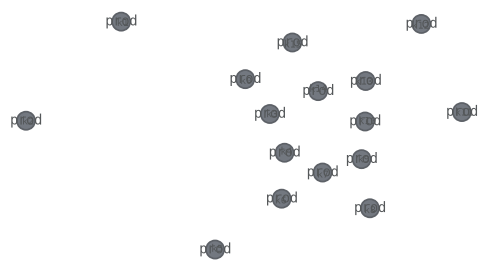

In [110]:
product_psi.draw()

### Symmetry check

In [111]:
product_psi.outer_inds()

('k0',
 'k1',
 'k2',
 'k3',
 'k4',
 'k5',
 'k6',
 'k7',
 'k8',
 'k9',
 'k10',
 'k11',
 'k12',
 'k13',
 'k14',
 'k15')

In [112]:
symmetry_gates = [
    qu_M.reindex({
        'ks': f'k{i}', 'bs':f'b{i}',
        'kf': f'k{i+1}', 'bf':f'b{i+1}',
    })
    for i in range(0, 16, 2)
]

In [113]:
sym_product_psi = qtn.TensorNetwork(
    [
        product_psi.reindex({f'k{i}': f'b{i}' for i in range(16)}),
        *symmetry_gates
    ]
)

In [114]:
(
    cluster_psi & cluster_psi.conj()
).contract()

np.float64(0.9999999999999982)

In [115]:
(
    product_psi & product_psi.conj()
).contract()

np.float64(0.9999999999999982)

In [116]:
(
    sym_product_psi & sym_product_psi.conj()
).contract()

np.complex128(0.9999999999999982+0j)

In [117]:
(
    product_psi & sym_product_psi
).contract()

np.complex128(0.9999999999999982+0j)

So it's symmetric.

In [118]:
rho = get_rdm_from_quimb_psi(product_psi, domains_dict['symmetry_sites'])

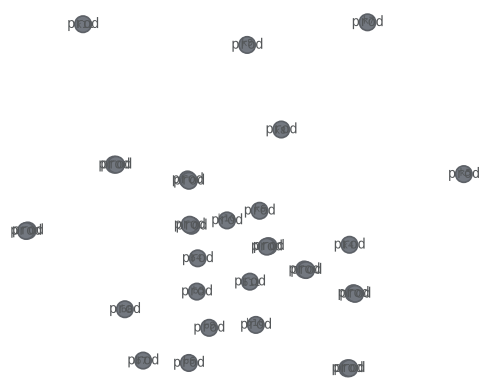

In [119]:
rho.draw()

In [120]:
rho.outer_inds()

('k4',
 'k5',
 'k6',
 'k7',
 'k8',
 'k9',
 'k10',
 'k11',
 'b4',
 'b5',
 'b6',
 'b7',
 'b8',
 'b9',
 'b10',
 'b11')

In [121]:
rho_purity = get_purity_from_quimb_rdm(rho)
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)

In [122]:
rho_purity

0.9999999999999964

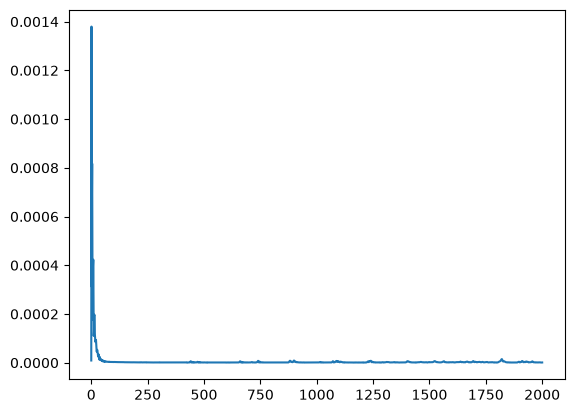

In [123]:
plt.plot(opt_out[1])

In [124]:
opt_out[1][-10:]

[1.430511474609375e-06,
 1.1920928955078125e-06,
 1.0728836059570312e-06,
 7.152557373046875e-07,
 7.152557373046875e-07,
 7.152557373046875e-07,
 8.344650268554688e-07,
 1.0728836059570312e-06,
 7.152557373046875e-07,
 9.5367431640625e-07]

## Partial conjugation defect operators

In [125]:
defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(
    rho,
    opt_out[0],
    domains_dict,
    partial_conjugation=True
)

In [126]:
np.round(defect_opt_out[0], 3)

array([1., 0., 0., 0., 0., 0., 0.])

In [127]:
defect_opt_out[3]

np.complex128(0.999999862719551+0j)

In [128]:
defect_opt_out[4]

np.complex128(0.9999999994400242+0j)

In [129]:
defect_opt_out[-2]

[np.float64(0.9092508197724664),
 np.float64(0.9998070360655964),
 np.float64(0.9998070360656406),
 np.float64(0.99980703606564),
 np.float64(0.9998070360656408),
 np.float64(0.9998070360656408),
 np.float64(0.9998070360656405),
 np.float64(0.9998070360656403),
 np.float64(0.9998070360656413),
 np.float64(0.9998070360656403),
 np.float64(0.9998070360656407),
 np.float64(0.9998070360656404),
 np.float64(0.9998070360656407),
 np.float64(0.9998070360656404),
 np.float64(0.999807036065641),
 np.float64(0.9998070360656404),
 np.float64(0.9998070360656409),
 np.float64(0.9998070360656403),
 np.float64(0.9998070360656409),
 np.float64(0.9998070360656406),
 np.float64(0.9998070360656406),
 np.float64(0.9998070360656403),
 np.float64(0.999807036065641),
 np.float64(0.9998070360656403),
 np.float64(0.9998070360656407),
 np.float64(0.9998070360656408),
 np.float64(0.9998070360656409),
 np.float64(0.9998070360656405),
 np.float64(0.9998070360656407),
 np.float64(0.9998070360656405),
 np.float64(0.

In [130]:
defect_opt_out[1]

Tensor(shape=(4, 4), inds=('kl', 'bl'), tags=oset([]))

In [131]:
np.round(defect_opt_out[1].data, 3)

array([[-0.035-0.023j, -0.003-0.021j,  0.553-0.832j,  0.01 +0.009j],
       [-0.009+0.011j,  0.119+0.015j,  0.009-0.01j , -0.513-0.85j ],
       [ 0.553-0.832j,  0.003+0.02j , -0.035-0.023j, -0.01 -0.01j ],
       [-0.02 +0.002j, -0.705+0.698j,  0.021-0.002j, -0.12 -0.015j]])

In [132]:
left_fuse_map = {
    'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
    'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
}
right_fuse_map = {
    'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
    'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
}

In [133]:
left_fuse_map

{'kl': ['k4', 'k5'], 'bl': ['b4', 'b5']}

In [134]:
left_defect_op = defect_opt_out[1].unfuse(
    left_fuse_map,
    shape_map={'kl': [2,2], 'bl': [2,2]}
)

In [135]:
left_decomp = qtn.tensor_core.tensor_split(
    left_defect_op,
    left_inds=['k4', 'b4'],
    method='svd',
    #cutoff=1e-3,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vRV'
)

In [136]:
left_decomp.tensors[1].data

array([1.79581905, 0.87964873, 0.03114621, 0.01679196])

Well approximated as not entangled.

In [137]:
np.round(defect_opt_out[2].data, 3)

array([[-0.317+0.164j, -0.021+0.01j , -0.43 -0.829j,  0.011-0.024j],
       [ 0.024+0.01j ,  0.199-0.961j, -0.024-0.01j ,  0.185+0.033j],
       [-0.43 -0.829j,  0.021-0.01j , -0.317+0.164j, -0.011+0.024j],
       [ 0.011+0.021j, -0.184-0.043j, -0.011-0.021j, -0.202+0.96j ]])

In [138]:
right_defect_op = defect_opt_out[2].unfuse(
    right_fuse_map,
    shape_map={'kr': [2,2], 'br': [2,2]}
)

In [139]:
np.round(right_defect_op.data, 3)

array([[[[-0.317+0.164j, -0.021+0.01j ],
         [-0.43 -0.829j,  0.011-0.024j]],

        [[ 0.024+0.01j ,  0.199-0.961j],
         [-0.024-0.01j ,  0.185+0.033j]]],


       [[[-0.43 -0.829j,  0.021-0.01j ],
         [-0.317+0.164j, -0.011+0.024j]],

        [[ 0.011+0.021j, -0.184-0.043j],
         [-0.011-0.021j, -0.202+0.96j ]]]])

In [140]:
right_fuse_map

{'kr': ['k10', 'k11'], 'br': ['b10', 'b11']}

In [141]:
right_decomp = qtn.tensor_core.tensor_split(
    right_defect_op,
    left_inds=['k10', 'b10'],
    method='svd',
    #cutoff=1e-3,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vRV'
)

In [142]:
right_decomp.tensors[1].data

array([1.417731  , 1.40979032, 0.03564836, 0.03548607])

## No partial conjugation defect operators

In [143]:
defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(
    rho,
    opt_out[0],
    domains_dict,
    partial_conjugation=False
)

In [144]:
np.round(defect_opt_out[0], 3)

array([1.])

In [145]:
defect_opt_out[3]

np.complex128(0.999999999999999+0j)

In [146]:
defect_opt_out[4]

np.complex128(0.999999999999998+0j)

In [147]:
defect_opt_out[5][-10:]

[np.float64(0.999999999999998),
 np.float64(0.9999999999999982),
 np.float64(0.9999999999999988),
 np.float64(0.9999999999999977),
 np.float64(0.999999999999998),
 np.float64(0.9999999999999982),
 np.float64(0.9999999999999988),
 np.float64(0.9999999999999977),
 np.float64(0.999999999999998),
 np.float64(0.9999999999999982)]

Good overlaps. How to compute the invariant?

In [148]:
defect_opt_out[1]

Tensor(shape=(4, 4), inds=('kl', 'bl'), tags=oset([]))

In [149]:
np.round(defect_opt_out[1].data, 3)

array([[ 0.902-0.237j,  0.   -0.j   , -0.092-0.348j,  0.   -0.j   ],
       [ 0.   -0.j   ,  0.   -1.j   ,  0.   -0.j   ,  0.   -0.j   ],
       [-0.092-0.348j,  0.   -0.j   ,  0.902-0.237j,  0.   -0.j   ],
       [ 0.   -0.j   ,  0.   -0.j   ,  0.   -0.j   ,  1.   -0.j   ]])

In [150]:
left_fuse_map = {
    'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
    'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
}
right_fuse_map = {
    'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
    'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
}

In [151]:
left_fuse_map

{'kl': ['k4', 'k5'], 'bl': ['b4', 'b5']}

In [152]:
left_defect_op = defect_opt_out[1].unfuse(
    left_fuse_map,
    shape_map={'kl': [2,2], 'bl': [2,2]}
)

In [153]:
left_decomp = qtn.tensor_core.tensor_split(
    left_defect_op,
    left_inds=['k4', 'b4'],
    method='svd',
    #cutoff=1e-3,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vRV'
)

In [154]:
left_decomp.tensors[1].data

array([1.82192522, 0.82497788])

Well approximated as not entangled.

In [155]:
np.round(defect_opt_out[2].data, 3)

array([[ 0.796+0.605j,  0.   -0.j   ,  0.015-0.019j,  0.   -0.j   ],
       [-0.   +0.j   , -0.707+0.707j,  0.   -0.j   ,  0.   -0.j   ],
       [ 0.015-0.019j,  0.   -0.j   ,  0.796+0.605j,  0.   -0.j   ],
       [ 0.   -0.j   ,  0.   -0.j   ,  0.   -0.j   ,  1.   -0.j   ]])

In [156]:
right_defect_op = defect_opt_out[2].unfuse(
    right_fuse_map,
    shape_map={'kr': [2,2], 'br': [2,2]}
)

In [157]:
right_fuse_map

{'kr': ['k10', 'k11'], 'br': ['b10', 'b11']}

In [158]:
right_decomp = qtn.tensor_core.tensor_split(
    right_defect_op,
    left_inds=['k10', 'b10'],
    method='svd',
    #cutoff=1e-3,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vRV'
)

In [159]:
right_decomp.tensors[1].data

array([1.66287035, 1.11124353])

Ok, definitely getting cleaner results here without partial conjugation, worth pursuing.

In [160]:
right_defect_op

Tensor(shape=(2, 2, 2, 2), inds=('k10', 'k11', 'b10', 'b11'), tags=oset([]))

In [161]:
np.round(right_defect_op.data, 3)

array([[[[ 0.796+0.605j,  0.   -0.j   ],
         [ 0.015-0.019j,  0.   -0.j   ]],

        [[-0.   +0.j   , -0.707+0.707j],
         [ 0.   -0.j   ,  0.   -0.j   ]]],


       [[[ 0.015-0.019j,  0.   -0.j   ],
         [ 0.796+0.605j,  0.   -0.j   ]],

        [[ 0.   -0.j   ,  0.   -0.j   ],
         [ 0.   -0.j   ,  1.   -0.j   ]]]])

# Debug
## get_rho_tilde step through

In [162]:
mps_decomp=opt_out[0]

In [163]:
mps_decomp

TensorNetwork(tensors=8, indices=17)

In [164]:
# rho_tilde is a reduced density matrix with the bra part complex conjugated
A = mps_decomp

# Left side
A_l = A.tensors[next(iter(A.ind_map['vLV']))]
k_left_ind = min(domains_dict['symmetry_sites'])
dummy_left_index = f'vH{k_left_ind}'

tn_l = (
    A_l
    &
    A_l.conj().reindex({
        f'k{k_left_ind}': f'b{k_left_ind}',
        dummy_left_index: 'dl',
    })
)
tn_l = tn_l.contract()

left_decomp = qtn.tensor_core.tensor_split(
    tn_l,
    left_inds=[f'k{k_left_ind}', dummy_left_index],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

# Right side
A_r = A.tensors[next(iter(A.ind_map['vRV']))]
k_right_ind = max(domains_dict['symmetry_sites'])
dummy_right_index = f'vH{k_right_ind-1}'

tn_r = (
    A_r
    &
    A_r.conj().reindex({
        f'k{k_right_ind}': f'b{k_right_ind}',
        dummy_right_index: 'dr',
    })
)
tn_r = tn_r.contract()

right_decomp = qtn.tensor_core.tensor_split(
    tn_r,
    left_inds=[f'k{k_right_ind}', dummy_right_index],
    method='svd',
    #cutoff=1e-3,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vRV'
)

ket_tensors = [
    *left_decomp.tensors[:-1],
    *[t for t in mps_decomp.tensors[1:-1]],
    *right_decomp.tensors[:-1]
]

bra_tensors = [
    left_decomp.tensors[-1].conj().reindex({'dl': dummy_left_index}),
    *[
        t.reindex({f'k{i}': f'b{i}'})
        for t, i in zip(mps_decomp.tensors[1:-1], domains_dict['symmetry_sites'][1:-1])
    ],
    right_decomp.tensors[-1].conj().reindex({'dr': dummy_right_index})
]

ket_tn = qtn.TensorNetwork(ket_tensors)
bra_tn = qtn.TensorNetwork(bra_tensors).mangle_inner_()

rho_tilde = ket_tn & bra_tn

In [165]:
domains_dict

{'num_system_sites': 16,
 'symmetry_sites': [4, 5, 6, 7, 8, 9, 10, 11],
 'left_defect_sites': [4, 5],
 'right_defect_sites': [10, 11],
 'mps_horizontal_bond_dimension': 8,
 'mps_vertical_bond_dimension': 8}

In [166]:
A_r

Tensor(shape=(8, 2, 8), inds=('vH10', 'k11', 'vRV'), tags=oset([]))

In [167]:
k_right_ind

11

In [168]:
dummy_right_index

'vH10'

In [169]:
dummy_right_index

'vH10'

In [170]:
tn_r

Tensor(shape=(8, 2, 8, 2), inds=('vH10', 'k11', 'dr', 'b11'), tags=oset([]))

In [171]:
dummy_right_index

'vH10'

In [172]:
ket_tensors

[Tensor(shape=(2, 8, 16), inds=('k4', 'vH4', 'vLV'), tags=oset([]), left_inds=('k4', 'vH4')),
 Tensor(shape=(16,), inds=('vLV',), tags=oset([])),
 Tensor(shape=(8, 2, 8), inds=('vH4', 'k5', 'vH5'), tags=oset([])),
 Tensor(shape=(8, 2, 8), inds=('vH5', 'k6', 'vH6'), tags=oset([])),
 Tensor(shape=(8, 2, 8), inds=('vH6', 'k7', 'vH7'), tags=oset([])),
 Tensor(shape=(8, 2, 8), inds=('vH7', 'k8', 'vH8'), tags=oset([])),
 Tensor(shape=(8, 2, 8), inds=('vH8', 'k9', 'vH9'), tags=oset([])),
 Tensor(shape=(8, 2, 8), inds=('vH9', 'k10', 'vH10'), tags=oset([])),
 Tensor(shape=(2, 8, 16), inds=('k11', 'vH10', 'vRV'), tags=oset([]), left_inds=('k11', 'vH10')),
 Tensor(shape=(16,), inds=('vRV',), tags=oset([]))]

In [173]:
"""
# Should give 1
right_defect_op_invariant = (
    rho_defect_r
    & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
    & right_defect_operator.conj().reindex({'kr': 'ki1', 'br': 'br'})
)
right_defect_op_invariant=right_defect_op_invariant.contract()
"""

"\n# Should give 1\nright_defect_op_invariant = (\n    rho_defect_r\n    & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})\n    & right_defect_operator.conj().reindex({'kr': 'ki1', 'br': 'br'})\n)\nright_defect_op_invariant=right_defect_op_invariant.contract()\n"